In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when

spark = SparkSession.builder.appName("ParquetQualityCheck").getOrCreate()
df = spark.read.parquet("/ProyectoIA/vinted-ai-spark-api/data/fashion_dataset.parquet")

total_registros = df.count()
print(f"📊 Total de registros iniciales: {total_registros}")

id_unico=df.select("id").distinct().count()
print(f"🔑 Total de IDs únicos: {id_unico}")

print("\n🔍 Recuento de nulos por columna:")
df.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in ["id", "articleType", "baseColour", "productDisplayName", "image"]
]).show()

null_images = df.filter(col("image.bytes").isNull()).count()
print(f"🖼️ Imágenes sin bytes (corruptas/nulas): {null_images}")

📊 Total de registros iniciales: 22036
🔑 Total de IDs únicos: 22036

🔍 Recuento de nulos por columna:
+---+-----------+----------+------------------+-----+
| id|articleType|baseColour|productDisplayName|image|
+---+-----------+----------+------------------+-----+
|  0|          0|         0|                 0|    0|
+---+-----------+----------+------------------+-----+

🖼️ Imágenes sin bytes (corruptas/nulas): 0


e:\ProyectoIA\vinted-ai-spark-api\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\usuario\AppData\Local\Temp\ipykernel_2968\44755273.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


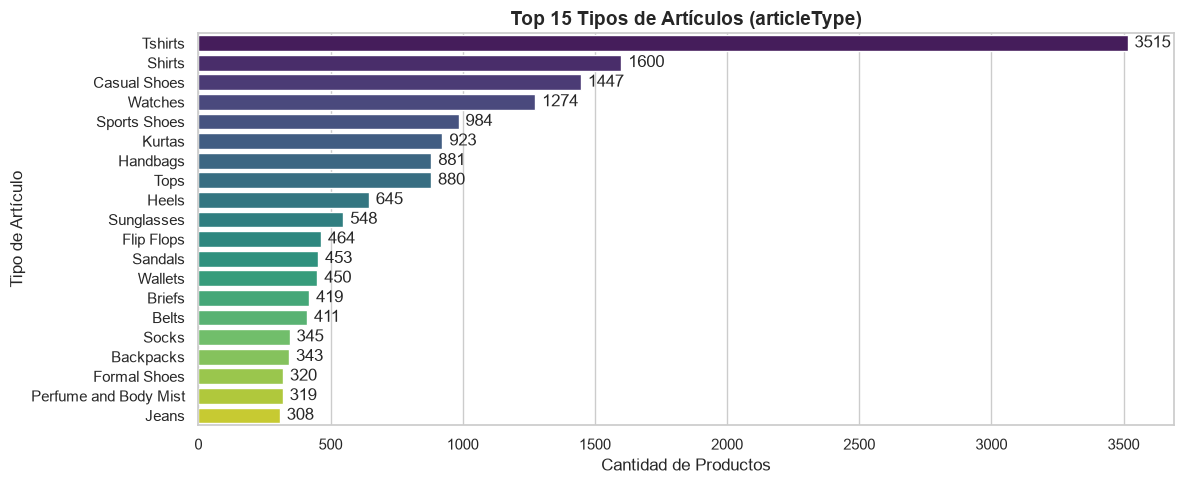

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, count

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ---------------------------------------------------------
# 1. Gráfico para 'articleType' (Top 20 tipos de artículo)
# ---------------------------------------------------------
top_articles_df = (
    df.groupBy("articleType")
    .agg(count("id").alias("count"))
    .orderBy(col("count").desc())
    .limit(20)
    .toPandas()
)

plt.figure(figsize=(12, 5))
ax1 = sns.barplot(
    data=top_articles_df, 
    x="count", 
    y="articleType", 
    palette="viridis"
)
plt.title("Top 20 Tipos de Artículos (articleType)", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de Productos")
plt.ylabel("Tipo de Artículo")

# Añadir el número exacto al final de cada barra
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(
        f"{int(width)}",
        (width, p.get_y() + p.get_height() / 2.),
        ha="left", va="center",
        xytext=(5, 0), textcoords="offset points"
    )

plt.tight_layout()
plt.show()

e:\ProyectoIA\vinted-ai-spark-api\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\usuario\AppData\Local\Temp\ipykernel_2968\4088097460.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


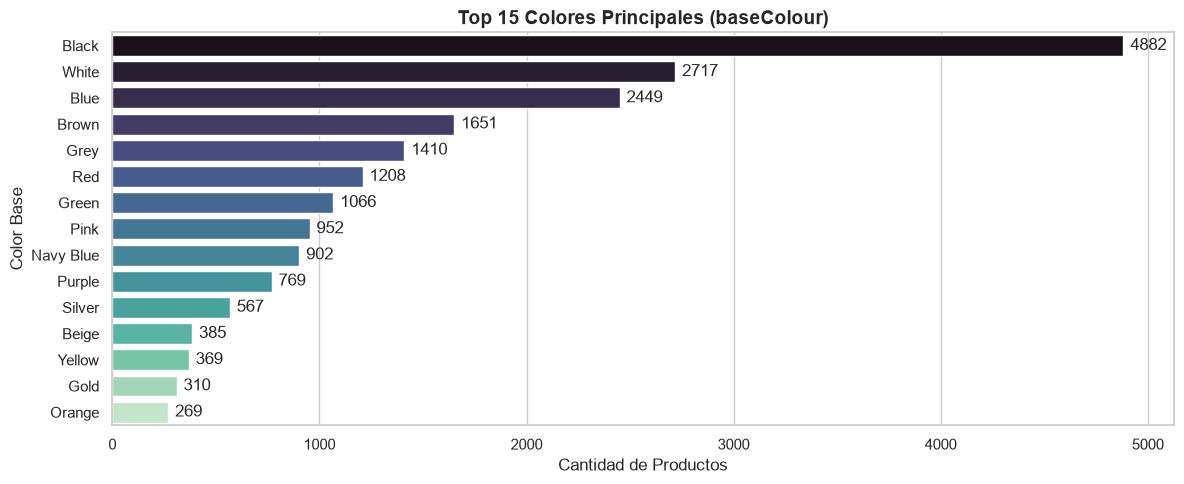

In [15]:
# ---------------------------------------------------------
# 2. Gráfico para 'baseColour' (Top 15 colores principales)
# ---------------------------------------------------------
top_colors_df = (
    df.groupBy("baseColour")
    .agg(count("id").alias("count"))
    .orderBy(col("count").desc())
    .limit(15)
    .toPandas()
)

plt.figure(figsize=(12, 5))
ax2 = sns.barplot(
    data=top_colors_df, 
    x="count", 
    y="baseColour", 
    palette="mako"
)
plt.title("Top 15 Colores Principales (baseColour)", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de Productos")
plt.ylabel("Color Base")

# Añadir el número exacto al final de cada barra
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f"{int(width)}",
        (width, p.get_y() + p.get_height() / 2.),
        ha="left", va="center",
        xytext=(5, 0), textcoords="offset points"
    )

plt.tight_layout()
plt.show()